In [130]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sadamumer/seoul-bike-hourly-rentals-and-weather-20172018/Seoul-bicycle-rental-dataset.csv


In [131]:
df_bike=pd.read_csv('/kaggle/input/datasets/sadamumer/seoul-bike-hourly-rentals-and-weather-20172018/Seoul-bicycle-rental-dataset.csv')
df_bike.head()

,Date,Rented Bike Count,Hour,Temperature(蚓),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(蚓),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [132]:
df_bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   object 
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(蚓)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(蚓)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   object 
 12  Holiday                   8760 non-null   object 
 13  Functioning Day           8760 non-null   object 
dtypes: float

In [133]:
df_bike.isna().sum()

Date                        0
Rented Bike Count           0
Hour                        0
Temperature(蚓)              0
Humidity(%)                 0
Wind speed (m/s)            0
Visibility (10m)            0
Dew point temperature(蚓)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
dtype: int64

In [134]:
df_bike.describe()

,Rented Bike Count,Hour,Temperature(蚓),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(蚓),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [135]:
df_bike.shape

(8760, 14)

In [136]:
df_bike['Date'] = pd.to_datetime(df_bike['Date'], format='%d/%m/%Y') 
df_bike['Date']

0      2017-12-01
1      2017-12-01
2      2017-12-01
3      2017-12-01
4      2017-12-01
          ...    
8755   2018-11-30
8756   2018-11-30
8757   2018-11-30
8758   2018-11-30
8759   2018-11-30
Name: Date, Length: 8760, dtype: datetime64[ns]

In [137]:
df_bike = df_bike.rename(columns={
    'Temperature(蚓)': 'Temperature',
    'Dew point temperature(蚓)': 'Dew point temperature'
})

In [138]:
df_bike['Holiday'] = df_bike['Holiday'].map({'No Holiday':0, 'Holiday':1})
df_bike['Functioning Day'] = df_bike['Functioning Day'].map({'No':0, 'Yes':1})

In [139]:
df_bike = pd.get_dummies(df_bike, columns=['Seasons'], drop_first=True)

In [140]:
df_bike.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Seasons_Spring,Seasons_Summer,Seasons_Winter
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,1,False,False,True
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,1,False,False,True
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,1,False,False,True


<Axes: xlabel='Hour'>

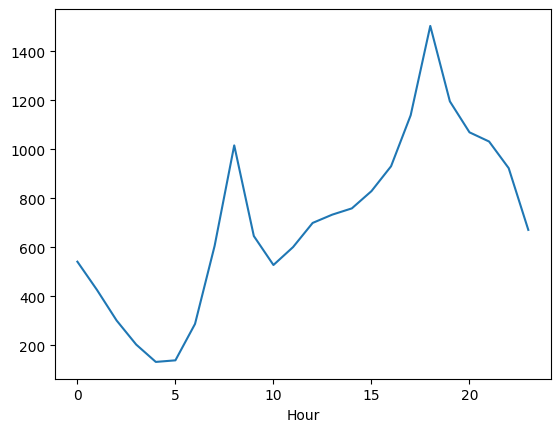

In [141]:
df_bike.groupby('Hour')['Rented Bike Count'].mean().plot()

In [142]:
serie_hours = df_bike.groupby('Hour')['Rented Bike Count'].mean()

print(f'Hour Max {serie_hours.idxmax()} ' )
print( f'Hour Min {serie_hours.idxmin()} ' )
print(f'Hours Mins {serie_hours.nsmallest(3)}')


Hour Max 18 
Hour Min 4 
Hours Mins Hour
4    132.591781
5    139.082192
3    203.331507
Name: Rented Bike Count, dtype: float64


- ## Early morning → low demand
- ## Morning → increases (start of the workday)
- ## Afternoon → peak (end of the workday)
- ## Night → decreases again

<Axes: xlabel='Temperature', ylabel='Rented Bike Count'>

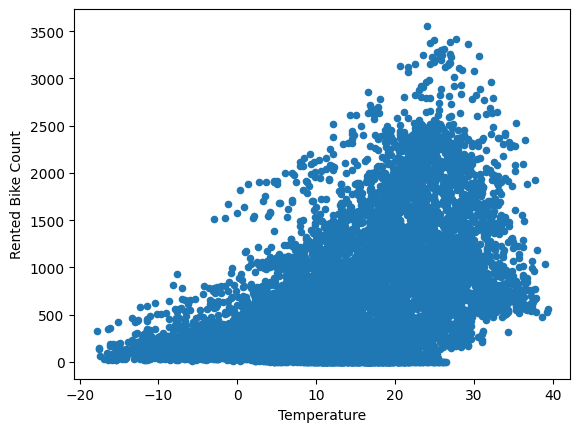

In [143]:

df_bike.plot.scatter(x='Temperature', y='Rented Bike Count')


# Rain has a strong negative impact on demand

<Axes: xlabel='Rainfall(mm)', ylabel='Rented Bike Count'>

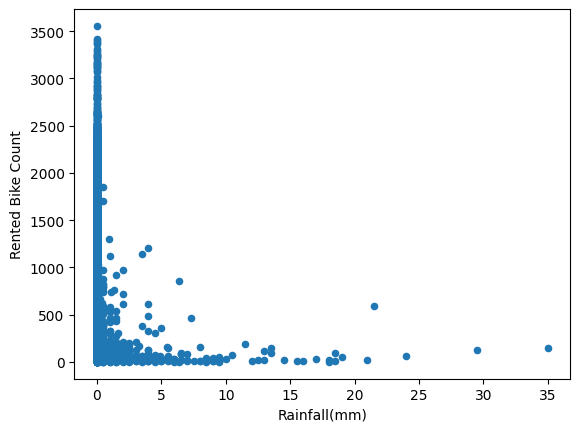

In [144]:
df_bike.plot.scatter(x='Rainfall(mm)', y='Rented Bike Count')

<Axes: xlabel='Hour'>

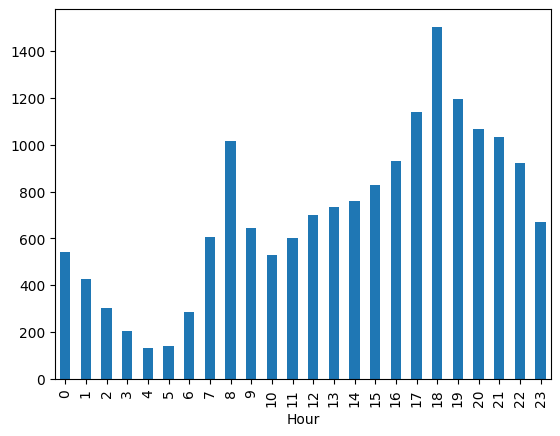

In [145]:
df_bike.groupby('Hour')['Rented Bike Count'].mean().plot(kind='bar')

In [146]:
corr_biker=df_bike.corr()['Rented Bike Count'].sort_values(ascending=False)
print(corr_biker.nlargest(4))
print('-----------------------------------------')
print(corr_biker.nsmallest(3))

Rented Bike Count        1.000000
Temperature              0.538558
Hour                     0.410257
Dew point temperature    0.379788
Name: Rented Bike Count, dtype: float64
-----------------------------------------
Seasons_Winter   -0.424925
Humidity(%)      -0.199780
Snowfall (cm)    -0.141804
Name: Rented Bike Count, dtype: float64


# Linear Regresion

In [147]:
from sklearn.model_selection import train_test_split

X = df_bike.drop(['Rented Bike Count','Date'], axis=1)
y = df_bike['Rented Bike Count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
X_train.shape

(7008, 14)

In [149]:
X_test.shape

(1752, 14)

In [150]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [151]:
y_pred = model.predict(X_test)
y_pred[:5]

array([ 954.81142423, 1145.20250953, 1358.60879696, 1330.05911176,
        550.82034735])

In [152]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(mae)

330.3852177498274


In [153]:
df_bike['Rented Bike Count'].describe()

count    8760.000000
mean      704.602055
std       644.997468
min         0.000000
25%       191.000000
50%       504.500000
75%      1065.250000
max      3556.000000
Name: Rented Bike Count, dtype: float64

In [154]:
percen_model = mae / df_bike['Rented Bike Count'].mean()

print(mae)
print(percen_model)
print(percen_model*100)

330.3852177498274
0.46889618828343604
46.88961882834361


In [155]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

In [156]:
percen_model = mae_rf / df_bike['Rented Bike Count'].mean()

print(mae_rf)
print(percen_model)
print(percen_model * 100)

145.4953710045662
0.2064929700595271
20.64929700595271


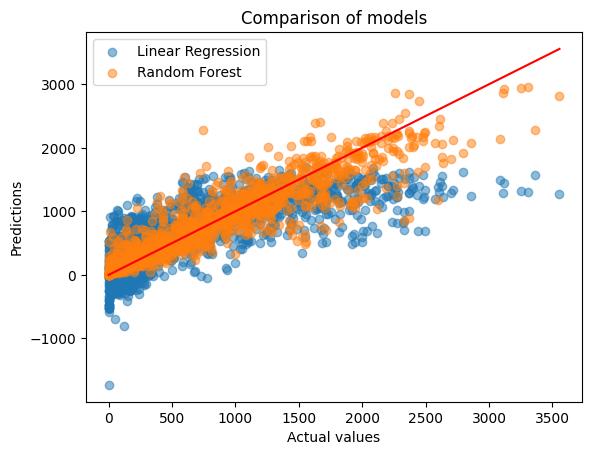

In [157]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5, label='Linear Regression')
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Random Forest')

plt.xlabel("Actual values")
plt.ylabel("Predictions")
plt.title("Comparison of models")

plt.legend()
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()